<a href="https://colab.research.google.com/github/ZackyRioOrlando/Praktikum-Pembelajaran-Mesin-/blob/main/JS06/JS06_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

💻
Lab 2

Klasifikasi SVM dengan Data Dummy Non-Linier

Langkah 1 - Ilustrasi Data Non-Linier

Data yang terpisah secara tidak linier menjadi masalah pada model SVM. Oleh karena itu, kernel menjadi sebuah kebutuhan bagi SVM untuk melakukan fitting pada hubungan non-linier dengan sebuah classifier linier.

Langkah 1a - Import Library

In [10]:
	# import library
	import numpy as np
	import matplotlib.pyplot as plt
	from scipy import stats
	import seaborn as sns
	from sklearn.svm import SVC

Langkah 1b - Buat Kembali Fungsi Plotting

In [11]:
	# buat sebuah fungsi untuk menampilkan fitting data

	def plot_svc_decision_function(model, ax=None, plot_support=True):

	    if ax is None:
	        ax = plt.gca()
	    xlim = ax.get_xlim()
	    ylim = ax.get_ylim()

	    # buat grid untuk evaluasi model
	    x = np.linspace(xlim[0], xlim[1], 30)
	    y = np.linspace(ylim[0], ylim[1], 30)
	    Y, X = np.meshgrid(y, x)
	    xy = np.vstack([X.ravel(), Y.ravel()]).T
	    P = model.decision_function(xy).reshape(X.shape)

	    # plot batas dan margin
	    ax.contour(X, Y, P, colors='k',
	               levels=[-1, 0, 1], alpha=0.5,
	               linestyles=['--', '-', '--'])

	    # plot support vectors
	    if plot_support:
	        ax.scatter(model.support_vectors_[:, 0],
	                   model.support_vectors_[:, 1],
	                   s=300, linewidth=1, facecolors='none');
	    ax.set_xlim(xlim)
	    ax.set_ylim(ylim)

Langkah 1c - Buat Data Dummy Non-Linier

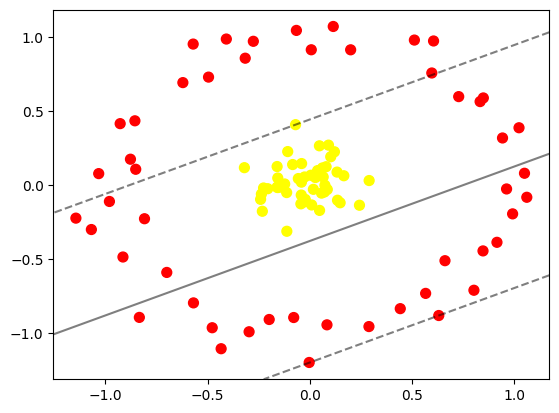

In [12]:
	# contoh data tidak terpisah secara linier
	from sklearn.datasets import make_circles
	X, y = make_circles(100, factor=.1, noise=.1)

	clf = SVC(kernel='linear').fit(X, y)

	plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
	plot_svc_decision_function(clf, plot_support=False);

In [13]:
r = np.exp(-(X**2).sum(1))

Karena proyeksi radial tidak cukup menggunakan model 2D, maka plot visualisasi diubah menjadi model 3D.

In [14]:
	from mpl_toolkits import mplot3d
	from ipywidgets import interact, fixed

	def plot_3D(elev=30, azim=30, X=X, y=y):
	    ax = plt.subplot(projection='3d')
	    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
	    ax.view_init(elev=elev, azim=azim)
	    ax.set_xlabel('x')
	    ax.set_ylabel('y')
	    ax.set_zlabel('r')

	interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azip=(-180, 180),
	         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[-2.41388629e-01, -9.59480114e-02],
       [-2.32884395e-01, -1.76452416e-01],
       [-1.13066234e-01, -3.11396511e-01],
       [-8.56011094e-01,  4.33989584e-01],
       [ 9.06535612e-02,  2.69768207e-01],
       [-8.52021692e-01,  1.06959328e-01],
       [-3.20625483e-01,  1.17758239e-01],
       [-1.14459407e+00, -2.22848632e-01],
       [ 1.04909968e+00,  8.00507773e-02],
       [-4.95960650e-01,  7.28844076e-01],
       [ 7.31457572e-02, -1.17275376e-03],
       [-4.08745964e-02,  1.45551697e-01],
       [ 8.32051459e-01,  5.63701203e-01],
       [-2.40007645e-02, -1.12109839e-01],
       [ 4.63126548e-02,  2.65290288e-01],
       [-6.63277248e-02,  1.04403307e+00],
       [-4.26191841e-02, -6.69816769e-02],
       [-1.08722138e-01,  2.26359890e-01],
       [-1.57704109e-01, -1.64564883e-02],
       [ 8.47062683e-02, -2.93921139e-02],
       [ 7.05911714e-02, -4.63168932e-02],
       [ 9.61465724e-01, -2.58816955e-02],
       [-1.06891664e+00, -2.99736146e-01],
       [ 1.19620840e-01,  2.24916518e-01],
       [-2.97632119e-01, -9.89578488e-01],
       [-4.34325373e-01, -1.10403346e+00],
       [ 6.47264928e-02,  5.50339749e-02],
       [ 1.06038651e+00, -8.20212750e-02],
       [-2.76932080e-01,  9.70509403e-01],
       [-3.16563073e-01,  8.56472893e-01],
       [-3.78752691e-03, -1.19686647e+00],
       [ 5.10659785e-01,  9.78857906e-01],
       [ 8.31773515e-02, -9.42792238e-01],
       [-8.34316418e-01, -8.92667955e-01],
       [-4.17955255e-02,  1.99490948e-02],
       [-7.94494746e-02, -8.93486989e-01],
       [-4.77957701e-01, -9.62432410e-01],
       [ 1.47506359e-01, -1.19167017e-01],
       [-2.62528698e-02,  5.48689786e-02],
       [-4.44095661e-02, -1.26395258e-01],
       [ 2.65678351e-02,  5.11608062e-02],
       [-2.26935373e-01, -1.94309408e-02],
       [-8.46898744e-02,  1.38807639e-01],
       [ 7.89210904e-02,  1.24156251e-01],
       [-1.23668091e-01,  7.72851273e-03],
       [ 1.02227560e+00,  3.87105969e-01],
       [ 1.32403301e-01,  8.79918851e-02],
       [ 1.65646844e-01,  6.32617414e-02],
       [ 8.01807935e-01, -7.09441497e-01],
       [ 9.91002302e-01, -1.94006845e-01],
       [ 1.01607397e-01,  1.91251607e-01],
       [ 6.60262052e-01, -5.10022951e-01],
       [-1.60591168e-01,  1.25391248e-01],
       [ 8.47776723e-01,  5.88296903e-01],
       [ 4.41626066e-01, -8.33652827e-01],
       [-9.14470624e-01, -4.85127707e-01],
       [-7.00141940e-01, -5.89226897e-01],
       [-2.30317252e-02, -9.63482937e-02],
       [ 2.36634411e-02,  6.22992279e-02],
       [ 5.65675117e-01, -7.30630458e-01],
       [ 6.44287244e-03,  9.13387100e-01],
       [-4.41290875e-02,  3.33494152e-02],
       [ 5.95825418e-01,  7.56722279e-01],
       [ 1.99011111e-01,  9.13132957e-01],
       [ 8.39644298e-03, -1.33918271e-01],
       [-5.71076889e-01,  9.51824484e-01],
       [-2.06457480e-01, -2.42742385e-02],
       [ 6.10347928e-02,  1.15779454e-01],
       [-1.13911750e-01, -5.02593416e-02],
       [ 9.41633297e-01,  3.18133490e-01],
       [-1.03301309e+00,  7.76430423e-02],
       [-4.08935410e-01,  9.85796957e-01],
       [ 4.01114872e-03,  6.66165194e-02],
       [ 8.46228803e-01, -4.43979405e-01],
       [-8.77773753e-01,  1.74827963e-01],
       [ 3.71915364e-02,  9.79162445e-02],
       [-5.69619810e-01, -7.94735182e-01],
       [ 1.34788952e-01, -1.02120768e-01],
       [-7.04028995e-02,  4.07979035e-01],
       [ 5.67078763e-02, -5.39867728e-02],
       [-8.09080392e-01, -2.26793459e-01],
       [ 2.88457976e-01, -9.54505448e-01],
       [-1.99321574e-01, -9.06800393e-01],
       [ 2.42142605e-01, -1.35799953e-01],
       [-5.68148854e-02,  4.42464651e-02],
       [ 6.04413330e-01,  9.72710144e-01],
       [-1.57370700e-01,  4.78494916e-02],
       [ 2.89418688e-01,  3.09224797e-02],
       [-9.80651514e-01, -1.10268363e-01],
       [-2.37495394e-01, -6.03221261e-02],
       [ 4.70328564e-02, -1.70613391e-01],
       [ 1.66957227e-02, -2.83984467e-02

Langkah 2 - Fitting Model

In [15]:
	clf = SVC(kernel='rbf', C=1E6)
	clf.fit(X, y)

SVC(C=1000000.0)

Plot hasil decision boundaries dari kernel RBF

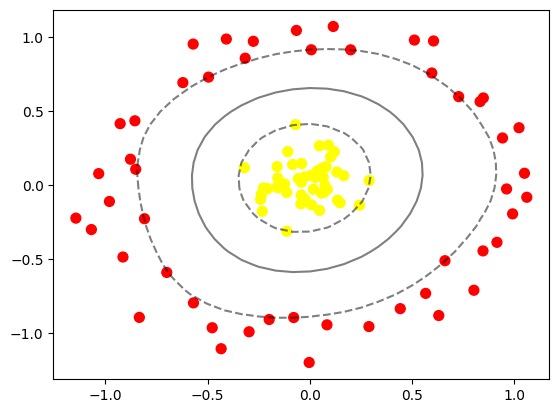

In [16]:
	plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
	plot_svc_decision_function(clf)
	plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
	            s=300, lw=1, facecolors='none')